## Stage 0 — World and LLM Setup

Identical to `runner.ipynb`: loads the PR2-apartment world, scopes grounding to physical `Body` instances.

In [1]:
from uniworld import load_pr2_apartment_world
from semantic_digital_twin.world_description.world_entity import Body

world, robot_view, context = load_pr2_apartment_world()
context.evaluate_conditions = False

symbol_type = Body
# print("World loaded:", type(world).__name__)
# print("Robot:", robot_view)

`polytope` failed to import `cvxopt.glpk`.
will use `scipy.optimize.linprog`
Unknown attribute "type" in /robot[@name='pr2']/link[@name='base_laser_link']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='wide_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='narrow_stereo_optical_frame']
Unknown attribute "type" in /robot[@name='pr2']/link[@name='laser_tilt_link']
Unknown tag "material" in /robot[@name='pr2']/link[@name='l_force_torque_link']/collision[1]
Unknown tag "material" in /robot[@name='apartment']/link[@name='coffe_machine']/collision[1]


In [2]:
from dotenv import load_dotenv
from llmr.reasoning.llm_provider import make_llm, LLMProvider

load_dotenv("../.env")

llm = make_llm(LLMProvider.OPENAI, model="gpt-4o-mini", temperature=0.0)
print("LLM ready:", getattr(llm, "model_name", llm))

LLM ready: gpt-4o-mini


In [3]:
# ROS setup
import rclpy
from semantic_digital_twin.adapters.ros.tf_publisher import TFPublisher
from semantic_digital_twin.adapters.ros.visualization.viz_marker import VizMarkerPublisher
rclpy.init()
_ros_node = rclpy.create_node('semantic_digital_twin')
import threading
_ros_thread = threading.Thread(target=rclpy.spin, args=(_ros_node,), daemon=True)
_ros_thread.start()

In [4]:
_tf_publisher = TFPublisher(_world=world, node=_ros_node)
_viz_publisher = VizMarkerPublisher(_world=world, node=_ros_node)
print("ROS2 publishers started")

ROS2 publishers started


## Stage 1 — Graph Bootstrap via `@hypothesis_family` Registry

**New in Phase 4**: the `@hypothesis_family(reasoner=...)` decorator registers each family in a global registry.
`HypothesisGraph.make_orchestrator()` reads that registry and wires all families automatically —
no manual `ProjectorRegistry([...])` construction.

```python
# Both families are registered at import time by the decorator:
@hypothesis_family(reasoner=FRAMENET_REASONER_NAME)
class FrameNetFamily(HypothesisFamily): ...

@hypothesis_family(reasoner=FLANAGAN_REASONER_NAME)
class FlanaganFamily(HypothesisFamily): ...
```

In [5]:
from llmr.hypotheses import (
    # graph core
    HypothesisGraph,
    # node types
    FrameHypothesisNode, FrameRoleHypothesisNode,
    MotionPlanHypothesisNode, MotionPhaseHypothesisNode,
    InstructionNode, ActionNode, ReasonerRunNode,
    SlotBindingEvidenceNode, SymbolGroundingEvidenceNode,
    # edge types
    HasRoleEdge, HasMotionPhaseEdge, GroundedByEdge, SupportedByEdge,
    # families
    FrameNetFamily, FlanaganFamily,
    get_all_families,
    # algorithms
    hypothesis_closure, reasoning_chain, conflicting_role_claims, invalidate_from_symbol,
    # linked navigation
    graph_context,
    # metadata enums
    ClaimStatus, GroundingState,
)
from llmr.hypotheses.common.nodes import ClaimNode, ContextNode, EvidenceNode, ReasonerClaimNode

# --- show what the registry knows about ---
print("Registered hypothesis families:")
for fam in get_all_families():
    print(f"  {fam.__name__:20s}  reasoner={fam.REASONER_NAME!r}")

# --- bootstrap with make_orchestrator() ---
graph = HypothesisGraph()
manager = graph.make_orchestrator()

print(f"\nOrchestrator projectors:")
for p in manager.registry.projectors:
    print(f"  {type(p).__name__}")

# family-specific views over the same graph
framenet = FrameNetFamily.make_view(graph)
flanagan = FlanaganFamily.make_view(graph)

print("\nGraph + views ready.")

Registered hypothesis families:
  FlanaganFamily        reasoner='flanagan_reasoner'
  FrameNetFamily        reasoner='framenet_reasoner'

Orchestrator projectors:
  FlanaganProjector
  FrameNetProjector

Graph + views ready.


## Stage 2 — Run Combined Inference

Both reasoners populate the same `HypothesisGraph` in a single `LLMBackend` evaluation.

In [6]:
from krrood.entity_query_language.query.match import Match
from llmr.backend import LLMBackend
from llmr.reasoning.framenet_reasoner import FrameNetReasoner
from llmr.reasoning.flanagan_reasoner import FlanaganReasoner
from pycram.datastructures.grasp import GraspDescription
from pycram.robot_plans.actions.core.pick_up import PickUpAction

INSTRUCTION = "pick up the milk from the table"


def fresh_pickup_match():
    return Match(PickUpAction)(
        object_designator=...,
        arm=...,
        grasp_description=Match(GraspDescription)(
            approach_direction=...,
            vertical_alignment=...,
            manipulator=...,
        ),
    )


def run_instruction(instruction: str, graph: HypothesisGraph, manager):
    backend = LLMBackend(
        llm=llm,
        symbol_type=symbol_type,
        instruction=instruction,
        strict_required=True,
        reasoners=[FrameNetReasoner(llm=llm), FlanaganReasoner(llm=llm)],
        hypothesis_graph_manager=manager,
    )
    action = next(iter(backend.evaluate(fresh_pickup_match())))
    return action, backend


action, backend = run_instruction(INSTRUCTION, graph, manager)

print("Resolved action:", type(action).__name__)
print("Resolved object:", action.object_designator)
print("Resolved arm:", action.arm)
print(f"Graph: {graph.node_count} nodes / {graph.edge_count} edges")
print(f"FrameNet claims: {len(framenet.claims())}")
print(f"Flanagan claims: {len(flanagan.claims())}")

Resolved action: PickUpAction
Resolved object: Body(name=PrefixedName('None/milk.stl'), id=UUID('d0bd97f6-97cd-4e6b-879f-3624fc2d38a7'), index=219)
Resolved arm: RIGHT
Graph: 22 nodes / 36 edges
FrameNet claims: 12
Flanagan claims: 4


## Stage 3 — MRO-Aware Domain Queries

**New in Phase 1**: `graph.domain(cls)` uses a per-class index built at insert time via MRO traversal.
Every concrete node is bucketed under its own type **and** all `HypothesisNode` superclasses.

This means querying `domain(ClaimNode)` returns every `FrameHypothesisNode`,
`FrameRoleHypothesisNode`, `MotionPlanHypothesisNode`, and `MotionPhaseHypothesisNode`
in O(1) — no `isinstance` scan over all nodes.

```
HypothesisNode (abstract, excluded from index)
├── ContextNode (abstract) → InstructionNode, ActionNode, ReasonerRunNode
├── ClaimNode   (abstract)
│   └── ReasonerClaimNode (abstract)
│       ├── FrameHypothesisNode, FrameRoleHypothesisNode
│       └── MotionPlanHypothesisNode, MotionPhaseHypothesisNode
└── EvidenceNode (abstract) → SlotBindingEvidenceNode, SymbolGroundingEvidenceNode
```

In [7]:
# 3a — concrete-type domain
frames = graph.domain(FrameHypothesisNode)
roles = graph.domain(FrameRoleHypothesisNode)
plans = graph.domain(MotionPlanHypothesisNode)
phases = graph.domain(MotionPhaseHypothesisNode)

print("Concrete domains:")
print(f"  FrameHypothesisNode     : {len(frames)}")
print(f"  FrameRoleHypothesisNode : {len(roles)}")
print(f"  MotionPlanHypothesisNode: {len(plans)}")
print(f"  MotionPhaseHypothesisNode: {len(phases)}")

# 3b — abstract-superclass domain (MRO-aware)
all_claims = graph.domain(ClaimNode)         # all FrameNet + Flanagan claims
all_evidence = graph.domain(EvidenceNode)    # SlotBinding + SymbolGrounding
all_context = graph.domain(ContextNode)      # Instruction + Action + Run
reasoner_claims = graph.domain(ReasonerClaimNode)  # same as ClaimNode here

print("\nAbstract superclass domains (MRO-aware):")
print(f"  ClaimNode        : {len(all_claims)} nodes")
print(f"  ReasonerClaimNode: {len(reasoner_claims)} nodes")
print(f"  EvidenceNode     : {len(all_evidence)} nodes")
print(f"  ContextNode      : {len(all_context)} nodes")
print(f"  Total accounted  : {len(all_claims) + len(all_evidence) + len(all_context)} / {graph.node_count} nodes")

# 3c — sibling branches are disjoint
claim_ids = {n.id for n in all_claims}
context_ids = {n.id for n in all_context}
evidence_ids = {n.id for n in all_evidence}
assert claim_ids.isdisjoint(context_ids) and claim_ids.isdisjoint(evidence_ids)
print("\nSanity: claim / context / evidence domains are pairwise disjoint ✓")

Concrete domains:
  FrameHypothesisNode     : 1
  FrameRoleHypothesisNode : 11
  MotionPlanHypothesisNode: 1
  MotionPhaseHypothesisNode: 3

Abstract superclass domains (MRO-aware):
  ClaimNode        : 16 nodes
  ReasonerClaimNode: 16 nodes
  EvidenceNode     : 2 nodes
  ContextNode      : 4 nodes
  Total accounted  : 22 / 22 nodes

Sanity: claim / context / evidence domains are pairwise disjoint ✓


In [8]:
# 3d — filter over abstract domain (replaces iter_nodes() + isinstance)
grounded_claims = [
    n for n in graph.domain(ClaimNode)
    if n.meta.grounding == GroundingState.SYMBOL_GROUNDED
]

supported_claims = [
    n for n in graph.domain(ClaimNode)
    if n.meta.status == ClaimStatus.SUPPORTED
]

framenet_hypotheses = [
    n for n in graph.domain(ClaimNode)
    if n.meta.source_reasoner == FrameNetFamily.REASONER_NAME
]

flanagan_hypotheses = [
    n for n in graph.domain(ClaimNode)
    if n.meta.source_reasoner == FlanaganFamily.REASONER_NAME
]

print("Filtered domain queries over ClaimNode:")
print(f"  symbol-grounded claims : {len(grounded_claims)}")
print(f"  supported claims       : {len(supported_claims)}")
print(f"  framenet claims        : {len(framenet_hypotheses)}")
print(f"  flanagan claims        : {len(flanagan_hypotheses)}")

# 3e — typed domain per reasoner run
run_nodes = graph.reasoner_runs
print(f"\nReasoner runs:")
for r in run_nodes:
    print(f"  {r.reasoner_name:25s}  run_id={r.meta.short_run_id}")

Filtered domain queries over ClaimNode:
  symbol-grounded claims : 1
  supported claims       : 1
  framenet claims        : 12
  flanagan claims        : 4

Reasoner runs:
  flanagan_reasoner          run_id=2df4be98
  framenet_reasoner          run_id=38217750


## Stage 4 — `get_instances_of_type` as EQL Instance Provider

**New in Phase 3**: `graph.get_instances_of_type(cls)` has the same signature as
`SymbolGraph.get_instances_of_type`. This makes `HypothesisGraph` a drop-in
domain source for EQL `variable()` queries.

```python
role = variable(FrameRoleHypothesisNode,
                domain=graph.get_instances_of_type(FrameRoleHypothesisNode))
```

The instance provider is backed by the MRO index, so it is O(1) regardless of graph size.

In [9]:
from krrood.entity_query_language.factories import an, entity, variable

# --- declare EQL variables backed by the instance provider ---
frame_var  = variable(FrameHypothesisNode,      domain=graph.get_instances_of_type(FrameHypothesisNode))
role_var   = variable(FrameRoleHypothesisNode,  domain=graph.get_instances_of_type(FrameRoleHypothesisNode))
plan_var   = variable(MotionPlanHypothesisNode, domain=graph.get_instances_of_type(MotionPlanHypothesisNode))
phase_var  = variable(MotionPhaseHypothesisNode,domain=graph.get_instances_of_type(MotionPhaseHypothesisNode))

# --- EQL query 1: frame for the exact instruction ---
q_frame = an(entity(frame_var).where(frame_var.instruction_text == INSTRUCTION))
frame_results = list(q_frame.evaluate())
print("Query 1 — frame for instruction:")
for f in frame_results:
    print(f"  frame={f.frame!r}  lexical_unit={f.lexical_unit!r}  label={f.framenet_label!r}")

# --- EQL query 2: entity-kind roles ---
q_entity_roles = an(entity(role_var).where(role_var.filler_kind == "entity"))
entity_roles = list(q_entity_roles.evaluate())
print("\nQuery 2 — entity-kind roles:")
for r in entity_roles:
    print(f"  role={r.role_name!r}  filler={r.filler_text!r}  grounding={r.meta.grounding.value}")

# --- EQL query 3: symbol-grounded roles ---
q_grounded = an(entity(role_var).where(role_var.meta.grounding == GroundingState.SYMBOL_GROUNDED))
grounded = list(q_grounded.evaluate())
print("\nQuery 3 — symbol-grounded roles:")
for r in grounded:
    print(f"  role={r.role_name!r}  filler={r.filler_text!r}  status={r.meta.status.value}")

Query 1 — frame for instruction:
  frame='Getting'  lexical_unit='pick_up.v'  label='picking_up_object'

Query 2 — entity-kind roles:
  role='agent'  filler='robot'  grounding=text_only
  role='theme'  filler='milk.stl'  grounding=symbol_grounded
  role='instrument'  filler='right_gripper'  grounding=text_only

Query 3 — symbol-grounded roles:
  role='theme'  filler='milk.stl'  status=supported


In [10]:
# --- EQL query 4: contact phases ---
q_contact = an(entity(phase_var).where(phase_var.contact == True))
contact_phases = list(q_contact.evaluate())
print("Query 4 — contact phases:")
for p in contact_phases:
    print(f"  phase={p.phase_name!r}  motion_type={p.motion_type!r}  urgency={p.urgency!r}")

# --- EQL query 5: high-urgency phases ---
q_urgent = an(entity(phase_var).where(phase_var.urgency == "high"))
urgent_phases = list(q_urgent.evaluate())
print("\nQuery 5 — high-urgency phases:")
for p in urgent_phases:
    print(f"  phase={p.phase_name!r}  target={p.target_object!r}  index={p.phase_index}")

# --- EQL query 6: cross-family — FrameNet theme filler vs Flanagan phase targets ---
q_theme = an(entity(role_var).where(role_var.role_name == "theme"))
theme_roles = list(q_theme.evaluate())
phase_targets = sorted({p.target_object for p in graph.domain(MotionPhaseHypothesisNode)})
theme_fillers = [r.filler_text for r in theme_roles]

print("\nQuery 6 — cross-family theme/target comparison:")
print(f"  FrameNet theme fillers : {theme_fillers}")
print(f"  Flanagan phase targets : {phase_targets}")

Query 4 — contact phases:
  phase='Grasp'  motion_type='pinch'  urgency='high'
  phase='Lift'  motion_type='upward_lift'  urgency='high'

Query 5 — high-urgency phases:
  phase='Grasp'  target='milk'  index=1
  phase='Lift'  target='milk'  index=2

Query 6 — cross-family theme/target comparison:
  FrameNet theme fillers : ['milk.stl']
  Flanagan phase targets : ['milk']


## Stage 5 — GraphLinked Navigation via `graph_context`

**New in Phase 3**: nodes that mix in `GraphLinked` expose attribute-style graph traversal.
`FrameHypothesisNode.roles` and `MotionPlanHypothesisNode.phases` navigate the graph
via `HasRoleEdge` / `HasMotionPhaseEdge` without the caller managing edge lookups.

Navigation requires an active graph context — set it with `graph.query_context()`
or the standalone `graph_context(graph)` context manager.

In [11]:
# 5a — frame.roles inside query context
current_frame = graph.domain(FrameHypothesisNode)[0]

with graph.query_context():
    frame_roles = current_frame.roles

print(f"frame={current_frame.frame!r}  lexical_unit={current_frame.lexical_unit!r}")
print(f"Roles attached via HasRoleEdge ({len(frame_roles)}):")
for r in frame_roles:
    print(f"  {r.role_name:15s}  filler={r.filler_text!r:20s}  kind={r.filler_kind}")

frame='Getting'  lexical_unit='pick_up.v'
Roles attached via HasRoleEdge (11):
  agent            filler='robot'               kind=entity
  theme            filler='milk.stl'            kind=entity
  instrument       filler='right_gripper'       kind=entity
  source           filler='table'               kind=place
  goal             filler="robot's grasp"       kind=place
  result           filler='robot holds milk.stl'  kind=state
  location         filler='kitchen area'        kind=place
  manner           filler='carefully'           kind=manner
  direction        filler='upward'              kind=motion
  purpose          filler='for transport'       kind=abstract
  quantity         filler='one milk'            kind=abstract


In [12]:
# 5b — plan.phases inside query context
current_plan = graph.domain(MotionPlanHypothesisNode)[0]

with graph.query_context():
    plan_phases = current_plan.phases

print(f"plan  action_type={current_plan.action_type!r}  phase_count={current_plan.phase_count}")
print(f"Phases attached via HasMotionPhaseEdge ({len(plan_phases)}):")
for ph in plan_phases:
    print(f"  [{ph.phase_index}] {ph.phase_name:12s}  target={ph.target_object!r}  contact={ph.contact}  urgency={ph.urgency!r}")

plan  action_type='PickUpAction'  phase_count=3
Phases attached via HasMotionPhaseEdge (3):
  [0] Approach      target='milk'  contact=False  urgency='medium'
  [1] Grasp         target='milk'  contact=True  urgency='high'
  [2] Lift          target='milk'  contact=True  urgency='high'


In [13]:
# 5c — multi-hop: entity-kind role fillers from all frames, in one expression
with graph.query_context():
    entity_fillers = [
        (frame.frame, role.role_name, role.filler_text)
        for frame in graph.get_instances_of_type(FrameHypothesisNode)
        for role in frame.roles
        if role.filler_kind == "entity"
    ]

print("Multi-hop — entity-kind role fillers across all frames:")
for frame_name, role_name, filler in entity_fillers:
    print(f"  frame={frame_name:12s}  role={role_name:12s}  filler={filler!r}")

# 5d — filter high-urgency phases via navigable accessor
with graph.query_context():
    high_urgency = [
        (plan.action_type, phase.phase_name, phase.urgency)
        for plan in graph.get_instances_of_type(MotionPlanHypothesisNode)
        for phase in plan.phases
        if phase.urgency == "high"
    ]

print("\nMulti-hop — high-urgency phases across all plans:")
for action_type, phase_name, urgency in high_urgency:
    print(f"  action={action_type}  phase={phase_name!r}  urgency={urgency!r}")

Multi-hop — entity-kind role fillers across all frames:
  frame=Getting       role=agent         filler='robot'
  frame=Getting       role=theme         filler='milk.stl'
  frame=Getting       role=instrument    filler='right_gripper'

Multi-hop — high-urgency phases across all plans:
  action=PickUpAction  phase='Grasp'  urgency='high'
  action=PickUpAction  phase='Lift'  urgency='high'


In [14]:
# 5e — linked_sources: who points INTO the frame?
# GraphLinked.linked_sources(edge_type, node_type) traverses incoming edges.
from llmr.hypotheses import EvokesFrameEdge, ProducedClaimEdge

with graph.query_context():
    evoking_instructions = current_frame.linked_sources(EvokesFrameEdge, InstructionNode)
    producing_runs = current_frame.linked_sources(ProducedClaimEdge, ReasonerRunNode)

print("linked_sources — who points INTO the frame:")
print(f"  EvokesFrameEdge sources (instructions): {[n.display_id for n in evoking_instructions]}")
print(f"  ProducedClaimEdge sources (runs)       : {[n.meta.short_run_id for n in producing_runs]}")

linked_sources — who points INTO the frame:
  EvokesFrameEdge sources (instructions): ['instruction:pick up the milk from the table']
  ProducedClaimEdge sources (runs)       : ['38217750']


## Stage 6 — Graph Algorithm Queries

**New in Phase 2** — four algorithms in `llmr.hypotheses.algorithms` that justify keeping `rustworkx`:

| Function | Description |
|---|---|
| `hypothesis_closure(graph, node_id)` | Full subgraph: ancestors ∪ descendants ∪ {node} |
| `reasoning_chain(graph, node_id)` | Shortest path from any instruction to node |
| `conflicting_role_claims(graph, action_ref)` | Same role name, different fillers |
| `invalidate_from_symbol(graph, symbol_ref)` | Propagate REFUTED status via ancestors |

### 6a — `hypothesis_closure`

In [15]:
# Closure of the frame node: all nodes reachable from it in either direction
frame_closure = hypothesis_closure(graph, current_frame.id)

print(f"Frame node     : {current_frame.display_id}")
print(f"Closure size   : {frame_closure.node_count} nodes / {frame_closure.edge_count} edges")
print(f"Closure nodes  :")
for node in frame_closure.iter_nodes():
    print(f"  {type(node).__name__:32s}  {node.display_id}")

Frame node     : framenet_reasoner:38217750:node:frame
Closure size   : 17 nodes / 27 edges
Closure nodes  :
  InstructionNode                   instruction:pick up the milk from the table
  ActionNode                        action:12334602
  ReasonerRunNode                   framenet_reasoner:38217750:node:run
  FrameHypothesisNode               framenet_reasoner:38217750:node:frame
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:agent
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:theme
  SlotBindingEvidenceNode           framenet_reasoner:38217750:node:slot_support:object_designator
  SymbolGroundingEvidenceNode       framenet_reasoner:38217750:node:symbol_grounding:theme
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:instrument
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:source
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:goa

In [16]:
# Closure of a role node — smaller, one branch of the frame subtree
theme_roles = [
    r for r in graph.domain(FrameRoleHypothesisNode)
    if r.role_name == "theme"
]
if theme_roles:
    theme_role = theme_roles[0]
    role_closure = hypothesis_closure(graph, theme_role.id)
    print(f"Role node      : {theme_role.display_id}")
    print(f"Closure size   : {role_closure.node_count} nodes / {role_closure.edge_count} edges")
    print("Closure nodes  :")
    for node in role_closure.iter_nodes():
        print(f"  {type(node).__name__:32s}  {node.display_id}")

Role node      : framenet_reasoner:38217750:node:role:core:theme
Closure size   : 6 nodes / 6 edges
Closure nodes  :
  InstructionNode                   instruction:pick up the milk from the table
  ReasonerRunNode                   framenet_reasoner:38217750:node:run
  FrameHypothesisNode               framenet_reasoner:38217750:node:frame
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:theme
  SlotBindingEvidenceNode           framenet_reasoner:38217750:node:slot_support:object_designator
  SymbolGroundingEvidenceNode       framenet_reasoner:38217750:node:symbol_grounding:theme


### 6b — `reasoning_chain`

Finds the shortest undirected path from any instruction node to the target claim.
This traces the provenance chain: instruction → frame → role → evidence.

In [17]:
# Chain to the frame node
frame_chain = reasoning_chain(graph, current_frame.id)

print(f"Reasoning chain to frame ({current_frame.display_id}):")
for i, node in enumerate(frame_chain):
    arrow = "→ " if i > 0 else "  "
    print(f"  {arrow}{type(node).__name__:32s}  {node.display_id}")

# Chain to a grounded role node — longer path through evidence
grounded_roles = [
    r for r in graph.domain(FrameRoleHypothesisNode)
    if r.meta.grounding == GroundingState.SYMBOL_GROUNDED
]
if grounded_roles:
    role_chain = reasoning_chain(graph, grounded_roles[0].id)
    print(f"\nReasoning chain to grounded role ({grounded_roles[0].display_id}):")
    for i, node in enumerate(role_chain):
        arrow = "→ " if i > 0 else "  "
        print(f"  {arrow}{type(node).__name__:32s}  {node.display_id}")

Reasoning chain to frame (framenet_reasoner:38217750:node:frame):
    InstructionNode                   instruction:pick up the milk from the table
  → FrameHypothesisNode               framenet_reasoner:38217750:node:frame

Reasoning chain to grounded role (framenet_reasoner:38217750:node:role:core:theme):
    InstructionNode                   instruction:pick up the milk from the table
  → FrameHypothesisNode               framenet_reasoner:38217750:node:frame
  → FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:theme


In [18]:
# Chain to a motion phase — should go via instruction → plan → phase
if graph.domain(MotionPhaseHypothesisNode):
    first_phase = graph.domain(MotionPhaseHypothesisNode)[0]
    phase_chain = reasoning_chain(graph, first_phase.id)
    print(f"Reasoning chain to motion phase ({first_phase.display_id}):")
    for i, node in enumerate(phase_chain):
        arrow = "→ " if i > 0 else "  "
        print(f"  {arrow}{type(node).__name__:32s}  {node.display_id}")

Reasoning chain to motion phase (flanagan_reasoner:2df4be98:node:phase:0:Approach):
    InstructionNode                   instruction:pick up the milk from the table
  → MotionPlanHypothesisNode          flanagan_reasoner:2df4be98:node:plan
  → MotionPhaseHypothesisNode         flanagan_reasoner:2df4be98:node:phase:0:Approach


### 6c — `conflicting_role_claims`

Detects FrameNet role nodes for the same action with the same `role_name` but different `filler_text`.
This fires when two reasoner runs produce competing interpretations for the same frame role.

We demonstrate by running the same instruction twice on the same action object, then manually
injecting a conflicting role claim to show the detector.

In [19]:
# Normal case: single run — no conflicts expected
conflicts_before = conflicting_role_claims(graph, action)
print(f"Conflicts in current graph: {len(conflicts_before)} (expected 0 for single run)")

# Synthetic conflict: inject a second 'theme' role with a different filler
# to simulate what happens when two runs disagree on the theme object.
from llmr.hypotheses import HypothesisMeta, EvokesFrameEdge

original_frame = graph.domain(FrameHypothesisNode)[0]
fn_run = [r for r in graph.reasoner_runs if r.reasoner_name == FrameNetFamily.REASONER_NAME][0]

conflicting_role = graph.add_node(
    FrameRoleHypothesisNode(
        id="demo_conflict_theme_role",
        meta=HypothesisMeta(
            source_reasoner=FrameNetFamily.REASONER_NAME,
            status=ClaimStatus.HYPOTHESIS,
            grounding=GroundingState.TEXT_ONLY,
            run_id=fn_run.run_id + "_v2",
        ),
        role_family="core",
        role_name="theme",              # same role name ...
        filler_text="breakfast_cereal", # ... different filler
        filler_kind="entity",
    )
)
graph.add_edge(
    HasRoleEdge(
        id="demo_conflict_edge",
        meta=HypothesisMeta(
            source_reasoner=FrameNetFamily.REASONER_NAME,
            status=ClaimStatus.HYPOTHESIS,
            grounding=GroundingState.TEXT_ONLY,
        ),
        src_id=original_frame.id,
        dst_id="demo_conflict_theme_role",
    )
)

conflicts_after = conflicting_role_claims(graph, action)
print(f"Conflicts after injection: {len(conflicts_after)}")
for r1, r2 in conflicts_after:
    print(f"  role={r1.role_name!r}: {r1.filler_text!r} ≠ {r2.filler_text!r}")

# clean up the demo nodes
graph.remove_node("demo_conflict_theme_role")
print(f"\nDemo nodes cleaned up. Conflicts now: {len(conflicting_role_claims(graph, action))}")

Conflicts in current graph: 0 (expected 0 for single run)
Conflicts after injection: 0

Demo nodes cleaned up. Conflicts now: 0


### 6d — `invalidate_from_symbol`

When the world state changes (e.g. the milk is no longer on the table), all hypothesis claims
that were grounded via that symbol should be marked `REFUTED`.

`invalidate_from_symbol` walks `rustworkx.ancestors()` from the grounding evidence node
up through `SupportedByEdge` / `GroundedByEdge` to all dependent `ClaimNode` ancestors.

In [20]:
# Find the symbol that was grounded (milk body)
symbol_groundings = graph.domain(SymbolGroundingEvidenceNode)
print(f"Symbol grounding evidence nodes: {len(symbol_groundings)}")
for ev in symbol_groundings:
    print(f"  {ev.display_id}  query={ev.query_text!r}  method={ev.grounding_method}")

if symbol_groundings:
    milk_symbol = symbol_groundings[0].symbol_ref
    print(f"\nSimulating world change: milk symbol is no longer valid")
    print(f"Before: status of grounded claims:")
    for n in graph.domain(ClaimNode):
        if n.meta.grounding == GroundingState.SYMBOL_GROUNDED:
            print(f"  {n.display_id}  status={n.meta.status.value}")

    affected = invalidate_from_symbol(graph, milk_symbol, new_status=ClaimStatus.REFUTED)

    print(f"\nAfter invalidation — {len(affected)} claims affected:")
    for n in affected:
        print(f"  {type(n).__name__:32s}  {n.display_id}  → status={n.meta.status.value}")

    # restore for subsequent cells
    for n in affected:
        n.meta.status = ClaimStatus.SUPPORTED
    print(f"\nRestored to SUPPORTED for subsequent queries.")

Symbol grounding evidence nodes: 1
  framenet_reasoner:38217750:node:symbol_grounding:theme  query='milk.stl'  method=resolved_slot_symbol_match

Simulating world change: milk symbol is no longer valid
Before: status of grounded claims:
  framenet_reasoner:38217750:node:role:core:theme  status=supported

After invalidation — 2 claims affected:
  FrameHypothesisNode               framenet_reasoner:38217750:node:frame  → status=refuted
  FrameRoleHypothesisNode           framenet_reasoner:38217750:node:role:core:theme  → status=refuted

Restored to SUPPORTED for subsequent queries.


## Stage 7 — Subgraph Queries

The graph supports three kinds of structural subgraph extraction:

| Method | Basis |
|---|---|
| `subgraph_for_action(action_ref)` | all nodes in the action's hypothesis closure |
| `subgraph_for_run(run_id)` | nodes/edges tagged with that run_id |
| `hypothesis_closure(graph, node_id)` | rustworkx ancestors ∪ descendants ∪ {node} |

In [21]:
action_subgraph = graph.subgraph_for_action(action)
fn_run_id = graph.domain(FrameHypothesisNode)[0].meta.run_id
fl_run_id = graph.domain(MotionPlanHypothesisNode)[0].meta.run_id
fn_run_subgraph = graph.subgraph_for_run(fn_run_id)
fl_run_subgraph = graph.subgraph_for_run(fl_run_id)

print(f"Full graph              : {graph.node_count:3d} nodes / {graph.edge_count:3d} edges")
print(f"action subgraph         : {action_subgraph.node_count:3d} nodes / {action_subgraph.edge_count:3d} edges")
print(f"FrameNet run subgraph   : {fn_run_subgraph.node_count:3d} nodes / {fn_run_subgraph.edge_count:3d} edges")
print(f"Flanagan run subgraph   : {fl_run_subgraph.node_count:3d} nodes / {fl_run_subgraph.edge_count:3d} edges")

# family views over run-local subgraphs
fn_run_view = FrameNetFamily.make_view(fn_run_subgraph)
fl_run_view = FlanaganFamily.make_view(fl_run_subgraph)
print(f"\nFrameNet run view: {len(fn_run_view.frames())} frame(s), {len(fn_run_view.roles())} role(s)")
print(f"Flanagan run view: {len(fl_run_view.plans())} plan(s), {len(fl_run_view.phases())} phase(s)")

Full graph              :  22 nodes /  36 edges
action subgraph         :  22 nodes /  36 edges
FrameNet run subgraph   :  17 nodes /  27 edges
Flanagan run subgraph   :   7 nodes /   9 edges

FrameNet run view: 1 frame(s), 11 role(s)
Flanagan run view: 1 plan(s), 3 phase(s)


In [22]:
# Algorithm-based closure vs run-based subgraph — they may differ:
# run-subgraph uses run_id tags; closure uses graph connectivity.
frame_alg_closure = hypothesis_closure(graph, current_frame.id)
fn_run_set = {n.id for n in fn_run_subgraph.iter_nodes()}
alg_set    = {n.id for n in frame_alg_closure.iter_nodes()}

only_in_run = fn_run_set - alg_set
only_in_alg = alg_set - fn_run_set

print("Comparison — FrameNet run subgraph vs hypothesis_closure(frame):")
print(f"  run-subgraph nodes     : {len(fn_run_set)}")
print(f"  algorithm closure nodes: {len(alg_set)}")
if only_in_run:
    print(f"  only in run (tagged, not connected): {only_in_run}")
if only_in_alg:
    print(f"  only in closure (connected, different run tag): {only_in_alg}")

Comparison — FrameNet run subgraph vs hypothesis_closure(frame):
  run-subgraph nodes     : 17
  algorithm closure nodes: 17


## Stage 8 — Multi-Run Graph

Run a second instruction on the same graph to demonstrate that
`domain()` queries and algorithm functions work correctly across multiple actions and runs.

In [23]:
INSTRUCTION_2 = "pick up the breakfast cereal from the counter"

action2, backend2 = run_instruction(INSTRUCTION_2, graph, manager)

print(f"Second instruction: {INSTRUCTION_2!r}")
print(f"Resolved action: {type(action2).__name__}")
print(f"Resolved object: {action2.object_designator}")
print(f"\nCombined graph: {graph.node_count} nodes / {graph.edge_count} edges")
print(f"FrameHypothesisNode  : {len(graph.domain(FrameHypothesisNode))} (one per instruction)")
print(f"FrameRoleHypothesisNode: {len(graph.domain(FrameRoleHypothesisNode))} (roles from both runs)")
print(f"MotionPlanHypothesisNode: {len(graph.domain(MotionPlanHypothesisNode))} (one plan per instruction)")
print(f"MotionPhaseHypothesisNode: {len(graph.domain(MotionPhaseHypothesisNode))} (phases from both plans)")

Second instruction: 'pick up the breakfast cereal from the counter'
Resolved action: PickUpAction
Resolved object: Body(name=PrefixedName('None/breakfast_cereal.stl'), id=UUID('408147a2-30d4-46eb-bd83-13a9554a6637'), index=220)

Combined graph: 44 nodes / 72 edges
FrameHypothesisNode  : 2 (one per instruction)
FrameRoleHypothesisNode: 22 (roles from both runs)
MotionPlanHypothesisNode: 2 (one plan per instruction)
MotionPhaseHypothesisNode: 6 (phases from both plans)


In [24]:
# Cross-run domain query: which frames were generated for each instruction?
print("All frames across both runs:")
for frame in graph.domain(FrameHypothesisNode):
    print(f"  frame={frame.frame!r:15s}  instruction={frame.instruction_text!r:50s}  run={frame.meta.short_run_id}")

# EQL variable over the combined graph — declared after second run
role_var2  = variable(FrameRoleHypothesisNode, domain=graph.get_instances_of_type(FrameRoleHypothesisNode))
q_entity2  = an(entity(role_var2).where(role_var2.filler_kind == "entity"))
entity_roles_all = list(q_entity2.evaluate())

print(f"\nEntity-kind roles across both instructions ({len(entity_roles_all)}):")
for r in entity_roles_all:
    print(f"  role={r.role_name:15s}  filler={r.filler_text!r:25s}  run={r.meta.short_run_id}")

All frames across both runs:
  frame='Getting'        instruction='pick up the milk from the table'                   run=38217750
  frame='Getting'        instruction='pick up the breakfast cereal from the counter'     run=522fd29f

Entity-kind roles across both instructions (6):
  role=agent            filler='robot'                    run=38217750
  role=theme            filler='milk.stl'                 run=38217750
  role=instrument       filler='right_gripper'            run=38217750
  role=agent            filler='robot'                    run=522fd29f
  role=theme            filler='breakfast_cereal.stl'     run=522fd29f
  role=instrument       filler='right_gripper'            run=522fd29f


In [25]:
# Action-scoped queries via subgraph_for_action —
# each action gets an independent view even in a shared graph.
action1_sub = graph.subgraph_for_action(action)
action2_sub = graph.subgraph_for_action(action2)

action1_view_fn = FrameNetFamily.make_view(action1_sub)
action2_view_fn = FrameNetFamily.make_view(action2_sub)
action1_view_fl = FlanaganFamily.make_view(action1_sub)
action2_view_fl = FlanaganFamily.make_view(action2_sub)

print("Per-action view summary:")
for label, fn_view, fl_view in [
    (INSTRUCTION[:40], action1_view_fn, action1_view_fl),
    (INSTRUCTION_2[:40], action2_view_fn, action2_view_fl),
]:
    frames = fn_view.frames()
    roles  = fn_view.roles()
    plans  = fl_view.plans()
    phases = fl_view.phases()
    contact= fl_view.contact_phases()
    print(f"  {label!r}")
    print(f"    FrameNet: {len(frames)} frame(s), {len(roles)} role(s)")
    print(f"    Flanagan: {len(plans)} plan(s), {len(phases)} phase(s), {len(contact)} contact phase(s)")

Per-action view summary:
  'pick up the milk from the table'
    FrameNet: 1 frame(s), 11 role(s)
    Flanagan: 1 plan(s), 3 phase(s), 2 contact phase(s)
  'pick up the breakfast cereal from the co'
    FrameNet: 1 frame(s), 11 role(s)
    Flanagan: 1 plan(s), 3 phase(s), 2 contact phase(s)


In [26]:
# Multi-run hypothesis_closure: closure of action2's frame stays isolated
frame2 = action2_view_fn.frames()[0]
closure2 = hypothesis_closure(graph, frame2.id)
closure1_ids = {n.id for n in hypothesis_closure(graph, current_frame.id).iter_nodes()}
closure2_ids = {n.id for n in closure2.iter_nodes()}

shared = closure1_ids & closure2_ids
print(f"Closure(action1 frame): {len(closure1_ids)} nodes")
print(f"Closure(action2 frame): {len(closure2_ids)} nodes")
if shared:
    print(f"Shared nodes (shared instruction dedup): {[n for n in shared]}")
else:
    print("Closures are fully disjoint (no shared instruction).")

Closure(action1 frame): 17 nodes
Closure(action2 frame): 17 nodes
Closures are fully disjoint (no shared instruction).


## Stage 9 — Visualization

The generic graph exposes `to_dot()` on any `HypothesisGraph` — including subgraphs
and algorithm-closure results. Node fill-colours distinguish node types;
edge labels show the relation name.

In [ ]:
# Action-local subgraph for the first instruction (both reasoners)
try:
    from graphviz import Source
    from IPython.display import display

    print("Action-1 subgraph (FrameNet + Flanagan combined):")
    display(Source(action1_sub.to_dot(), format="svg"))
except Exception as exc:
    print("Graphviz rendering unavailable:", exc)
    print(action1_sub.to_dot())

hypothesis_closure(framenet_reasoner:38217750:node:frame):


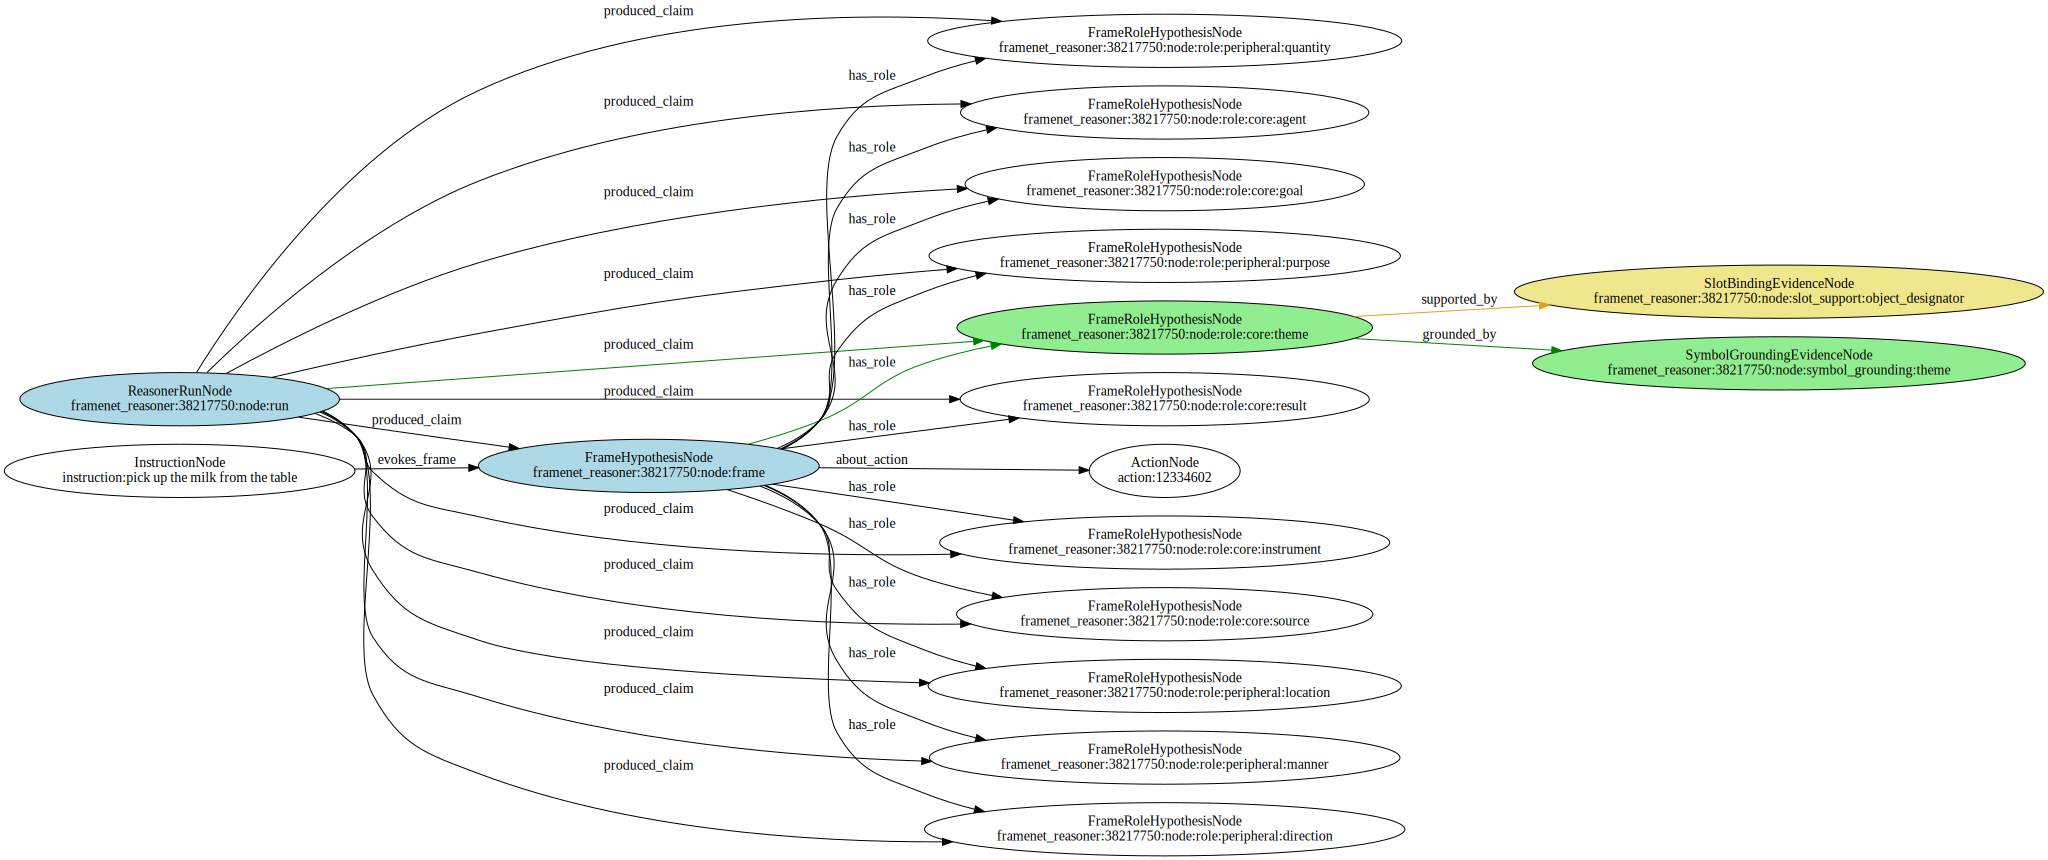

In [28]:
# hypothesis_closure subgraph for the FrameNet frame of action1
frame1_closure = hypothesis_closure(graph, current_frame.id)

try:
    from graphviz import Source
    from IPython.display import display

    print(f"hypothesis_closure({current_frame.display_id}):")
    display(Source(frame1_closure.to_dot(), format="svg"))
except Exception as exc:
    print("Graphviz rendering unavailable:", exc)
    print(frame1_closure.to_dot())

## Summary — API Reference

| API | Where | Use |
|---|---|---|
| `graph.domain(cls)` | `graph.py` | O(1) typed domain; MRO-aware |
| `graph.get_instances_of_type(cls)` | `graph.py` | KRROOD-compatible instance provider |
| `graph.make_orchestrator()` | `graph.py` | auto-wire all `@hypothesis_family` families |
| `get_all_families()` | `families/base.py` | inspect the global family registry |
| `graph.query_context()` | `graph.py` | context manager for GraphLinked navigation |
| `graph_context(graph)` | `linked.py` | standalone context manager |
| `node.roles` / `node.phases` | `framenet/nodes.py`, `flanagan/nodes.py` | edge-traversal via `GraphLinked` |
| `node.linked(edge_type)` | `linked.py` | generic outgoing edge traversal |
| `node.linked_sources(edge_type)` | `linked.py` | generic incoming edge traversal |
| `hypothesis_closure(graph, node_id)` | `algorithms.py` | rustworkx ancestors ∪ descendants |
| `reasoning_chain(graph, node_id)` | `algorithms.py` | shortest path from instruction |
| `conflicting_role_claims(graph, action)` | `algorithms.py` | same role, different fillers |
| `invalidate_from_symbol(graph, symbol)` | `algorithms.py` | propagate REFUTED via ancestors |